# aquela semana 6 de crias mesmo


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_moons, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
def plot_confusion_matrix_simple(cm, labels=("Negative", "Positive"), title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


In [3]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("water_potability_subset.csv")

print(f"Dataset loaded with {df.shape[0]} reviews.")
df.head()


Dataset loaded with 2000 reviews.


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.262799,206.889748,31414.525805,4.528076,349.734662,567.027274,15.963540,73.022605,4.012518,0
1,7.803833,223.688111,37376.792989,6.664969,NaN,343.764013,16.697408,74.782434,2.907387,0
2,8.692115,144.236358,2552.962804,9.202634,347.975137,517.427471,13.963421,42.388661,2.283475,0
3,7.344976,182.306942,5689.804405,6.764350,373.872785,360.184473,20.483902,73.488981,3.418763,0
4,6.527441,181.072995,22444.081777,10.474977,271.862792,351.063788,11.996365,NaN,3.567181,0


# precessamento de dados

In [4]:
df_prep=df.dropna()
df_prep

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.262799,206.889748,31414.525805,4.528076,349.734662,567.027274,15.963540,73.022605,4.012518,0
2,8.692115,144.236358,2552.962804,9.202634,347.975137,517.427471,13.963421,42.388661,2.283475,0
3,7.344976,182.306942,5689.804405,6.764350,373.872785,360.184473,20.483902,73.488981,3.418763,0
5,5.903994,196.274726,19399.221972,7.641895,328.269272,324.045681,18.505372,77.157802,3.820021,0
10,8.520807,238.335112,28779.650011,8.282808,381.649323,481.318803,6.016337,39.091171,3.940605,0
...,...,...,...,...,...,...,...,...,...,...
1992,5.646083,219.342932,22455.695012,8.283758,386.038790,401.256292,16.650114,31.174039,3.938506,1
1993,5.609235,216.122673,14825.934502,7.001788,355.211678,330.092674,9.779518,41.249977,3.224676,1
1994,7.732880,189.509811,47022.745845,8.226725,287.087053,567.722281,14.980054,71.206209,3.510728,1
1995,7.669013,205.595635,11579.441693,4.263279,356.136518,407.721613,10.829045,83.243808,4.589513,1


In [5]:
#split

X = df_prep.drop(columns="Potability")
y = df_prep["Potability"]

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().sort_index())
X.head()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Dataset shape: (1220, 9)
Class distribution:
Potability
0    593
1    627
Name: count, dtype: int64
Train shape: (976, 9)
Test shape:  (244, 9)


RAmdom forest

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 400],  # Number of trees in the forest
        "max_depth": [None, 3, 5, 10], # Maximum depth of the tree (None means unlimited)
        "min_samples_leaf": [1, 2, 4], # Minimum number of samples required to be at a leaf node
        "max_features": ["sqrt", 0.5], # how many features each tree is allowed to consider at each split
                          #sqrt -> max_features = √(n_features)
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)
print("Best CV accuracy:", round(rf_grid.best_score_, 4))


Best parameters:
{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 4, 'n_estimators': 100}
Best CV accuracy: 0.6495


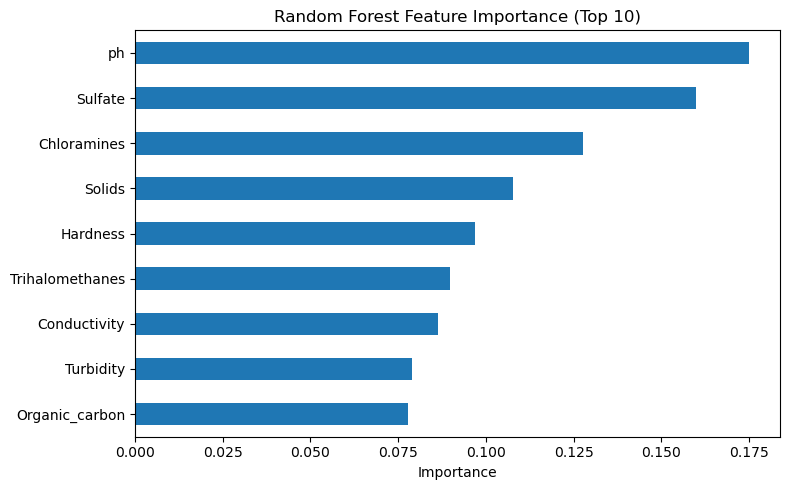

In [7]:
best_rf = rf_grid.best_estimator_

rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
rf_importances.head(10).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 10)")
plt.tight_layout()
plt.show()

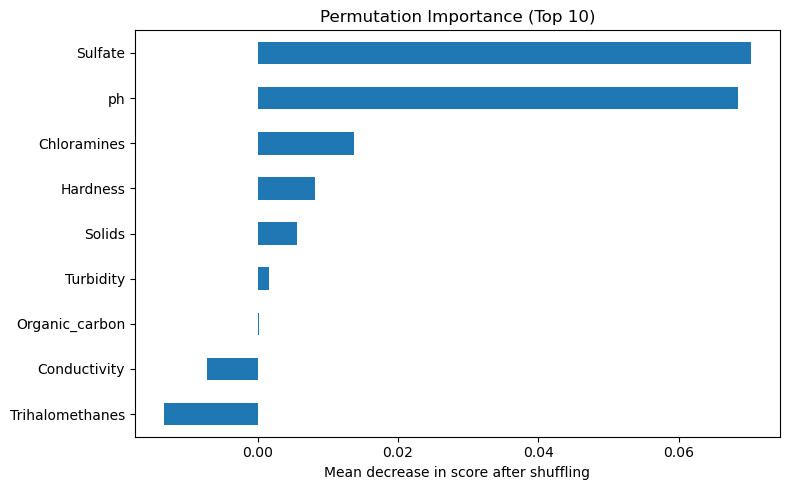

In [8]:
perm = permutation_importance(
    best_rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1
)

perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
perm_importances.head(10).sort_values().plot(kind="barh")
plt.xlabel("Mean decrease in score after shuffling")
plt.title("Permutation Importance (Top 10)")
plt.tight_layout()
plt.show()

In [10]:
test_proba = best_rf.predict_proba(X_test)[:, 1]
test_pred = best_rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("Average Precision:", round(average_precision_score(y_test, test_proba), 4))
print()
print(classification_report(y_test, test_pred, target_names=["nondrink", "drink"]))

Accuracy: 0.5943
ROC AUC: 0.6688
Average Precision: 0.7024

              precision    recall  f1-score   support

    nondrink       0.60      0.52      0.56       119
       drink       0.59      0.66      0.63       125

    accuracy                           0.59       244
   macro avg       0.59      0.59      0.59       244
weighted avg       0.59      0.59      0.59       244



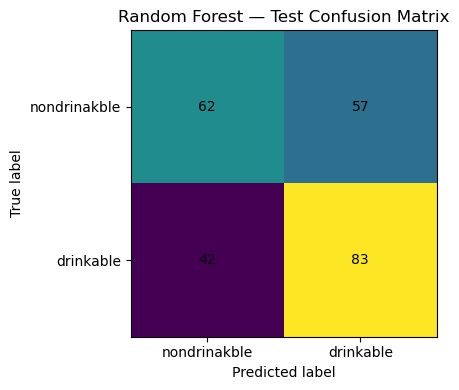

In [11]:
cm = confusion_matrix(y_test, test_pred)
plot_confusion_matrix_simple(cm, labels=("nondrinakble", "drinkable"), title="Random Forest — Test Confusion Matrix")

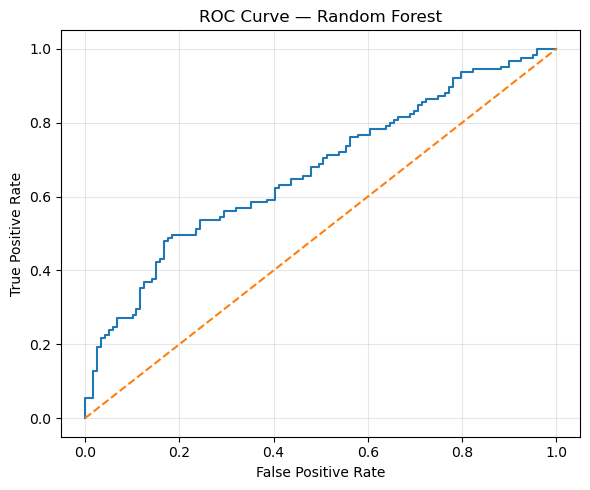

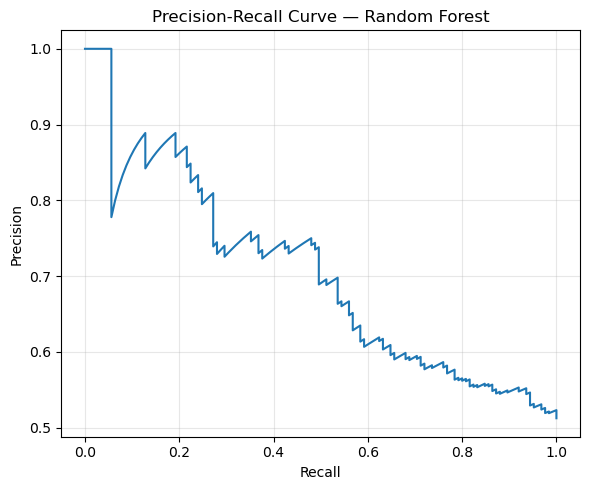

In [12]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
precision, recall, _ = precision_recall_curve(y_test, test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Base estimators
clf1 = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=1.0,
        random_state=42,
        solver="liblinear"
    ))
])

clf2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    max_features=0.5,
    min_samples_leaf=1,
    random_state=42
)

clf3 = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        C=3.0,
        kernel="rbf",
        gamma="scale",    ## gamma = 1 / (n_features * X.var()); adapts to data scale (good default)
        probability=True,
        random_state=42
    ))
])

# Soft voting ensemble
eclf1 = VotingClassifier(
    estimators=[("lr", clf1), ("rf", clf2), ("svc", clf3)],
    voting="soft",
    weights=[1, 2, 1]
)

eclf1.fit(X_train, y_train)

ensemble_pred = eclf1.predict(X_test)
ensemble_proba = eclf1.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, ensemble_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, ensemble_proba), 4))
print("Average Precision:", round(average_precision_score(y_test, ensemble_proba), 4))
print()
print(classification_report(y_test, ensemble_pred, target_names=["nondrinkable", "drinkable"]))

Accuracy: 0.5943
ROC AUC: 0.6729
Average Precision: 0.6901

              precision    recall  f1-score   support

nondrinkable       0.60      0.50      0.54       119
   drinkable       0.59      0.69      0.63       125

    accuracy                           0.59       244
   macro avg       0.60      0.59      0.59       244
weighted avg       0.60      0.59      0.59       244



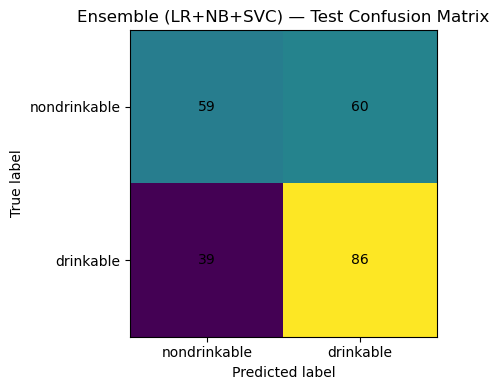

In [17]:
cm_ensemble = confusion_matrix(y_test, ensemble_pred)
plot_confusion_matrix_simple(cm_ensemble, labels=("nondrinkable", "drinkable"), title="Ensemble (LR+NB+SVC) — Test Confusion Matrix")